# 04 - Phase 1: Group Stage (pre-tournament)

The first of five phase notebooks. Each one freezes the tournament at the start of a round, trains a model on **only the matches available at that point** (strict point-in-time -- no look-ahead), and predicts what happens next; then, for rounds that have since been played, it scores those predictions against reality.

**This is the pre-tournament view.** The model is trained on every match played *before the 2026 group stage kicked off*, so it has never seen a single 2026 result. We predict (1) the win/draw/loss odds of each group fixture and (2) every team's chance of advancing to the knockout -- then check both against what actually happened.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wcpredictor.config import default_config
from wcpredictor.data import (load_matches, load_groups,
                              load_tournament_state,
                              build_training_matches, phase_start_dates)
from wcpredictor.data.tournament_state import GROUP_STAGE
from wcpredictor.models import PoissonModel
from wcpredictor.simulation import TournamentSimulator
from wcpredictor import visualization as viz

config = default_config()
plt.rcParams['figure.figsize'] = (9, 4.5)

## Point-in-time training

Cut the data at the first 2026 group match: the model sees only matches played strictly before it.

In [2]:
matches = load_matches(config)
dates = phase_start_dates(config)
cutoff = pd.Timestamp(dates[GROUP_STAGE])   # first 2026 group match
train = matches[matches['date'] < cutoff]
print(f'Group stage starts {cutoff.date()}.')
print(f'Training on {len(train)} pre-tournament matches; '
      f'holding out {len(matches) - len(train)} played since.')
tr = build_training_matches(train, config, reference_date=cutoff)
poisson = PoissonModel(config).fit(tr)

Group stage starts 2026-06-11.
Training on 964 pre-tournament matches; holding out 104 played since.


## Match-by-match group predictions

For every actual group fixture: the model's win / draw / loss probabilities (home perspective), the outcome it called most likely, and what really happened. We zoom into one group here; the accuracy summary that follows covers all 72 group matches.

In [3]:
r32_start = pd.Timestamp(dates['round_of_32'])
group_games = matches[(matches['tournament'] == 'World Cup 2026') &
                      (matches['date'] >= cutoff) &
                      (matches['date'] < r32_start)].copy()

def _predict_row(g):
    pred = poisson.predict_match(g['home_team'], g['away_team'],
                                 neutral=bool(g['neutral']))
    actual = ('H' if g['home_score'] > g['away_score']
              else 'A' if g['away_score'] > g['home_score'] else 'D')
    return pd.Series({
        'home': g['home_team'], 'away': g['away_team'],
        'p_home': round(pred.p_home_win, 3),
        'p_draw': round(pred.p_draw, 3),
        'p_away': round(pred.p_away_win, 3),
        'called': pred.most_likely,
        'score': f"{g['home_score']}-{g['away_score']}",
        'actual': actual, 'hit': pred.most_likely == actual})

preds = group_games.apply(_predict_row, axis=1)
example = sorted(load_groups(config)['group'].unique())[0]
in_group = set(load_groups(config).query('group == @example')['team'])
print(f'Group {example} fixtures:')
preds[preds['home'].isin(in_group) & preds['away'].isin(in_group)]

Group A fixtures:


/Users/SP13545/world-cup-predictor/src/wcpredictor/models/poisson.py:251: UserWarning: Team 'Curaçao' not seen in training data; using neutral attack/defense strengths.
  warnings.warn(
/Users/SP13545/world-cup-predictor/src/wcpredictor/models/poisson.py:251: UserWarning: Team 'Cape Verde' not seen in training data; using neutral attack/defense strengths.
  warnings.warn(
/Users/SP13545/world-cup-predictor/src/wcpredictor/models/poisson.py:251: UserWarning: Team 'Jordan' not seen in training data; using neutral attack/defense strengths.
  warnings.warn(
/Users/SP13545/world-cup-predictor/src/wcpredictor/models/poisson.py:251: UserWarning: Team 'Uzbekistan' not seen in training data; using neutral attack/defense strengths.
  warnings.warn(


,home,away,p_home,p_draw,p_away,called,score,actual,hit
964,South Korea,Czech Republic,0.392,0.264,0.344,H,2-1,H,True
965,Mexico,South Africa,0.414,0.277,0.309,H,2-0,H,True
988,Czech Republic,South Africa,0.357,0.258,0.385,A,1-1,D,False
989,Mexico,South Korea,0.400,0.284,0.316,H,1-0,H,True
1015,South Africa,South Korea,0.370,0.237,0.393,A,1-0,H,False
1016,Czech Republic,Mexico,0.275,0.306,0.419,A,0-3,A,True


## How good were the match predictions?

Scored across all 72 group games with accuracy, multiclass log-loss, and the ranked probability score (RPS) -- the standard metric for ordered football outcomes. Lower log-loss / RPS is better.

In [4]:
def _rps(row):
    order = ['H', 'D', 'A']
    p = np.array([row['p_home'], row['p_draw'], row['p_away']])
    y = np.eye(3)[order.index(row['actual'])]
    return np.sum((np.cumsum(p) - np.cumsum(y)) ** 2) / 2

def _p_actual(row):
    return {'H': row['p_home'], 'D': row['p_draw'],
            'A': row['p_away']}[row['actual']]

acc = preds['hit'].mean()
ll = -np.log(np.clip(preds.apply(_p_actual, axis=1), 1e-15, 1)).mean()
rps = preds.apply(_rps, axis=1).mean()
print(f'{len(preds)} group matches | accuracy {acc:.0%} | '
      f'log-loss {ll:.3f} | RPS {rps:.3f}')
print('(A three-way coin flip scores log-loss 1.099 / RPS ~0.22.)')

72 group matches | accuracy 60% | log-loss 0.920 | RPS 0.175
(A three-way coin flip scores log-loss 1.099 / RPS ~0.22.)


## Who progresses? (Monte Carlo, from scratch)

The odds above are single-game views. To turn them into *advancement* probabilities we simulate the whole group stage (and the knockout beyond) many times with `sim.run()` -- the pre-tournament projection in which all 48 teams still contend. Each team's finishing-position and advance probabilities fall out of the aggregate.

In [5]:
sim = TournamentSimulator(poisson, load_groups(config), config)
report = sim.run(n_simulations=config.simulation.n_simulations)
prog = report.table[['team', 'group', 'p_group_1st', 'p_group_2nd',
                     'p_group_3rd', 'p_group_4th', 'p_advance']]
prog.sort_values(['group', 'p_advance'],
                 ascending=[True, False]).head(12)

,team,group,p_group_1st,p_group_2nd,p_group_3rd,p_group_4th,p_advance
20,Mexico,A,0.3080,0.2688,0.2348,0.1884,0.7523
24,South Korea,A,0.2572,0.2449,0.2450,0.2529,0.6804
35,South Africa,A,0.2410,0.2418,0.2500,0.2672,0.6637
31,Czech Republic,A,0.1938,0.2445,0.2702,0.2915,0.6306
18,Bosnia & Herzegovina,B,0.4579,0.3468,0.1457,0.0496,0.9169
21,Switzerland,B,0.4199,0.3499,0.1659,0.0643,0.8963
41,Canada,B,0.0865,0.1915,0.3819,0.3401,0.5072
45,Qatar,B,0.0357,0.1118,0.3065,0.5460,0.3122
3,Brazil,C,0.6518,0.2297,0.0865,0.0320,0.9543
14,Morocco,C,0.2062,0.3851,0.2770,0.1317,0.7806


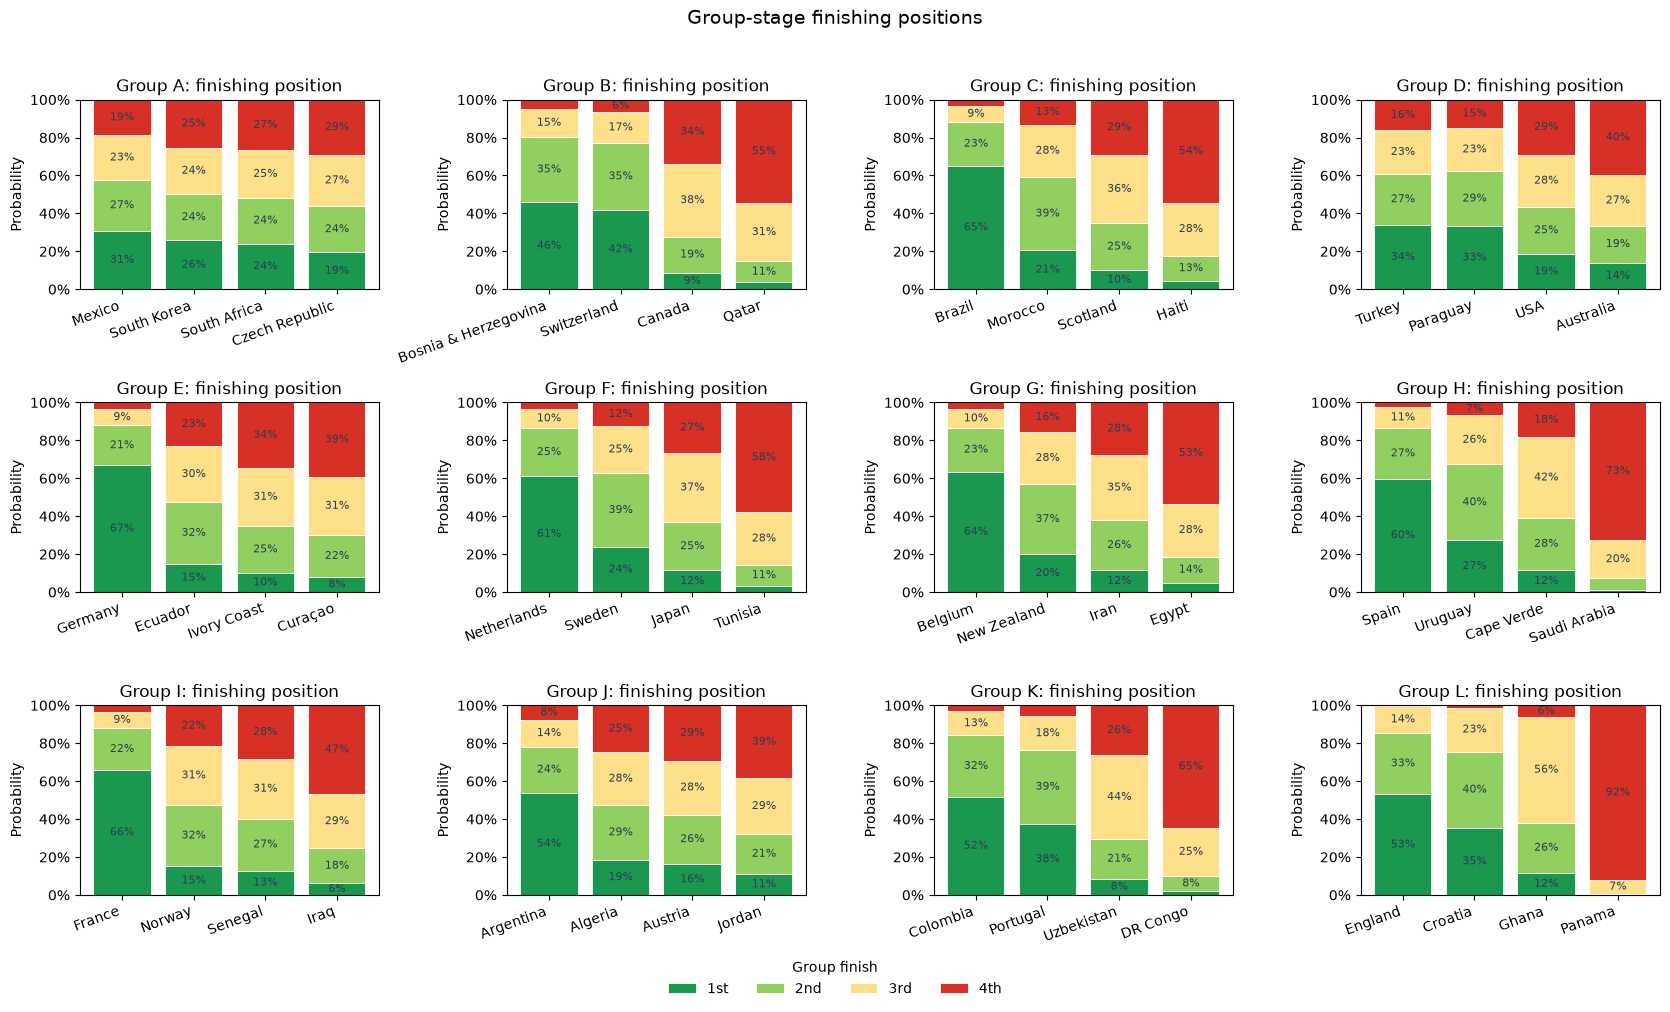

In [6]:
viz.plot_group_grid(report)
plt.show()

## Did the right teams progress?

The 32 teams that actually reached the knockout come straight from the played results (`load_tournament_state(...).reached`). We compare each team's simulated advance probability with whether it truly went through.

In [7]:
# The 32 knockout qualifiers = every team that turns up in the R32.
# (Rewinding to the R32 also means this keeps working once the whole
# tournament is decided, when the default un-rewound view has no
# frontier left to return.)
actual_adv = set(load_tournament_state(
    config, as_of_stage='round_of_32').reached)
adv = report.table[['team', 'p_advance']].copy()
adv['advanced'] = adv['team'].isin(actual_adv).astype(float)
p = adv['p_advance'].clip(1e-15, 1 - 1e-15)
brier = np.mean((adv['p_advance'] - adv['advanced']) ** 2)
ll = -np.mean(adv['advanced'] * np.log(p) +
              (1 - adv['advanced']) * np.log(1 - p))
top = set(adv.sort_values('p_advance', ascending=False)
          .head(len(actual_adv))['team'])
print(f'{len(adv)} teams | Brier {brier:.3f} | log-loss {ll:.3f}')
print(f'Of the {len(actual_adv)} teams we ranked most likely to advance, {len(top & actual_adv)} actually did.')
adv['surprise'] = adv['advanced'] - adv['p_advance']
cols = ['team', 'p_advance', 'advanced']
print('\nBiggest upsets (advanced despite low odds):')
display(adv.sort_values('surprise', ascending=False).head(5)[cols])
print('Biggest flops (favoured but eliminated):')
display(adv.sort_values('surprise').head(5)[cols])

48 teams | Brier 0.165 | log-loss 0.488
Of the 32 teams we ranked most likely to advance, 27 actually did.

Biggest upsets (advanced despite low odds):


,team,p_advance,advanced
44,DR Congo,0.2274,1.0
42,Egypt,0.3461,1.0
41,Canada,0.5072,1.0
37,Australia,0.5129,1.0
28,Ivory Coast,0.5336,1.0


Biggest flops (favoured but eliminated):


,team,p_advance,advanced
12,Uruguay,0.8644,0.0
15,Turkey,0.7758,0.0
25,New Zealand,0.7509,0.0
24,South Korea,0.6804,0.0
31,Czech Republic,0.6306,0.0


## Pre-tournament title odds

For completeness, the from-scratch championship picture *before a ball was kicked*.

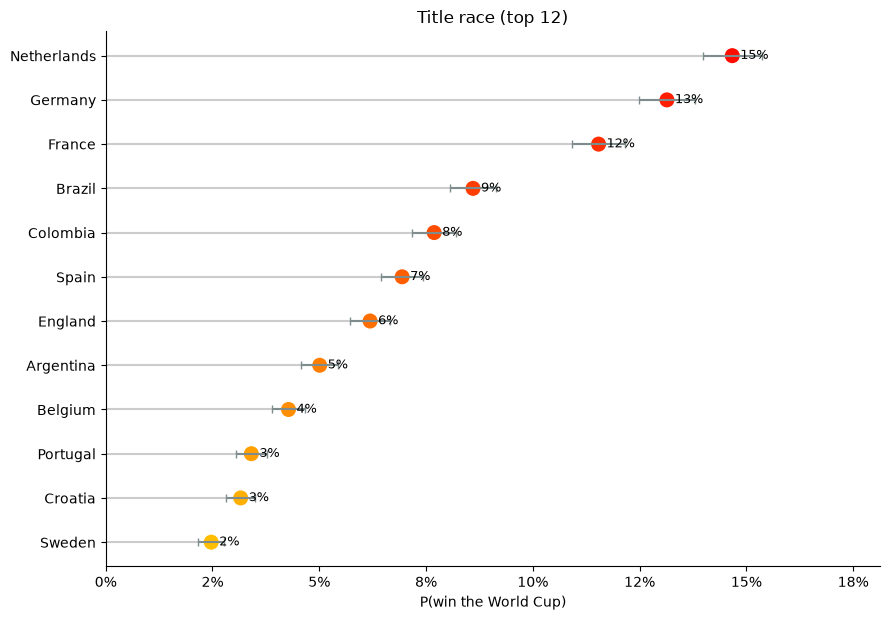

In [8]:
viz.plot_title_race(report, top_n=12)
plt.tight_layout(); plt.show()